/tmp/ipython-input-641387340.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_data = yf.download(tickers, period="5y")['Close']
[*********************100%***********************]  5 of 5 completed


Ticker             JNJ         KO          PG         VZ        WMT
Date                                                               
2020-09-28  127.555031  42.363579  121.955605  44.277809  42.675533
2020-09-29  127.511673  42.054096  121.292824  44.188313  42.641335
2020-09-30  129.089722  42.440941  122.821602  44.374790  43.502628
2020-10-01  127.737083  42.277607  123.042526  44.344948  44.488274
2020-10-02  126.800613  42.432343  122.052826  44.188313  43.686073


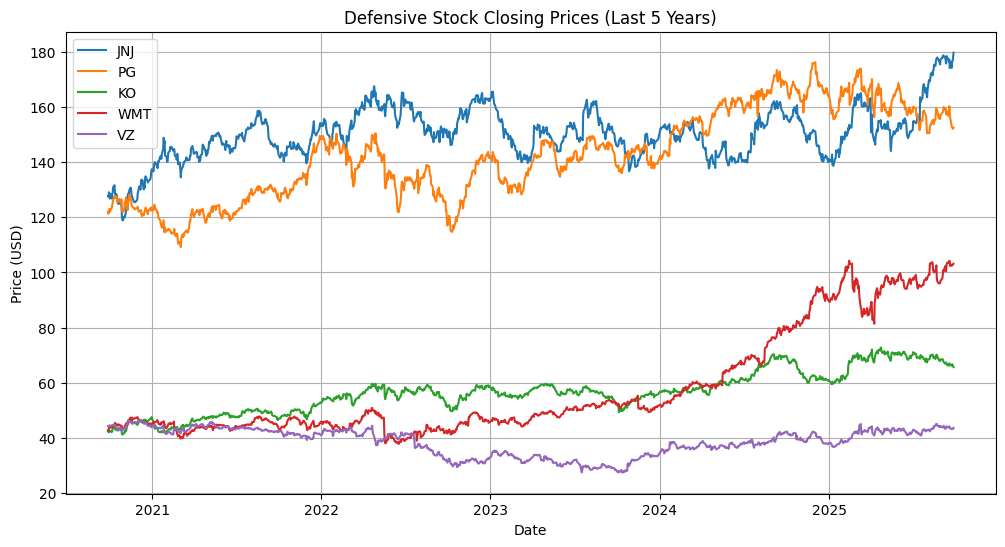

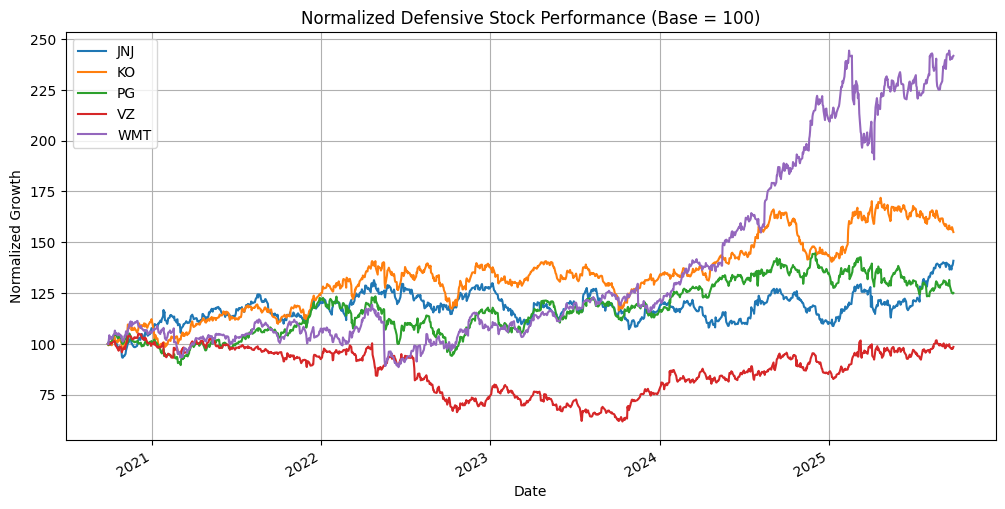

In [1]:
# Install yfinance if needed
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Defensive stock tickers
tickers = ["JNJ", "PG", "KO", "WMT", "VZ"]

# Download historical stock data (5 years)
historical_data = yf.download(tickers, period="5y")['Close']

# Display first 5 rows
print(historical_data.head())

# Plot closing prices
plt.figure(figsize=(12,6))
for stock in tickers:
    plt.plot(historical_data.index, historical_data[stock], label=stock)

plt.title("Defensive Stock Closing Prices (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Optional: normalized growth
normalized = historical_data / historical_data.iloc[0] * 100
normalized.plot(figsize=(12,6))
plt.title("Normalized Defensive Stock Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Growth")
plt.legend()
plt.grid(True)
plt.show()


In [2]:
#assume daily risk-free rate ~0.03% (approx 1% annual)
risk_free_rate = 0.03/252

#Daily Sharpe Ratio
daily_sharpe = (historical_data.pct_change().mean() - risk_free_rate) / historical_data.pct_change().std()

#Annualized Sharpe Ratio
annualized_sharpe = daily_sharpe * 252 ** 0.5

print("Daily Sharpe Ratios:")
print(daily_sharpe)

print("\nAnnualized Sharpe Ratios:")
print(annualized_sharpe)



Daily Sharpe Ratios:
Ticker
JNJ    0.019816
KO     0.027656
PG     0.010885
VZ    -0.003851
WMT    0.051651
dtype: float64

Annualized Sharpe Ratios:
Ticker
JNJ    0.314562
KO     0.439025
PG     0.172800
VZ    -0.061130
WMT    0.819942
dtype: float64
